# Mapper v4.2 — Contract diagnostics / interpretable mapper

Этот ноутбук теперь работает с **contract-scale** датасетом из `v4_01`.

Важно: колонка `z8_scaled_vector` в этом пайплайне означает **dB-contract vector**, а не percentile/statistical scale.

Смысл шкалы:

```text
z = 0.0  neutral
z = 0.5  mild
z = 1.0  noticeable
z = 1.5  strong
z = 2.0  extreme
```

Ноутбук проверяет:

1. состав mixed dataset;
2. распределение real и mixed `z8_contract`;
3. contract behavior ручного `InterpretableMapper8D`;
4. archetype / archetype_jitter кривые;
5. controllability metrics: basis alignment, target/off, scale coverage, cycle consistency.


In [1]:
from pathlib import Path
import sys
import importlib

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    MAPPER_DIR = NOTEBOOK_DIR.parent
else:
    MAPPER_DIR = NOTEBOOK_DIR
RESEARCH_DIR = MAPPER_DIR.parent
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

OUTPUT_DIR = MAPPER_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODELS_DIR = OUTPUT_DIR / "models"
for p in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, METRICS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mapper_v2.feature_space as fs
import mapper_v2.mapper_basis as mb
import mapper_v2.mapper_io as mio
import mapper_v2.mapper_plotting as mp
import mapper_v2.mapper_metrics as mm
importlib.reload(fs); importlib.reload(mb); importlib.reload(mio); importlib.reload(mp); importlib.reload(mm)

mp.use_article_style()

print("MAPPER_DIR:", MAPPER_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


MAPPER_DIR: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2
OUTPUT_DIR: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs


## 1. Load contract-mixed dataset

Ожидается, что `v4_01` уже сохранил:

```text
outputs/mapper_v4_scale_aligned_dataset.parquet
outputs/mapper_v4_feature_scale_normalizer.json
```

Имя файла оставлено старым для совместимости, но внутри `z8_scaled_vector == z8_contract_vector`.


In [2]:
DATASET_PATH = OUTPUT_DIR / "mapper_v4_scale_aligned_dataset.parquet"
NORMALIZER_PATH = OUTPUT_DIR / "mapper_v4_feature_scale_normalizer.json"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_PATH}. Run mapper_v4_01_scale_aligned_dataset.ipynb first."
    )
if not NORMALIZER_PATH.exists():
    raise FileNotFoundError(
        f"Normalizer not found: {NORMALIZER_PATH}. Run mapper_v4_01_scale_aligned_dataset.ipynb first."
    )

normalizer = fs.FeatureScaleNormalizer.load_json(NORMALIZER_PATH)
df, freqs_23 = mio.load_curve_dataset(DATASET_PATH)

def ensure_vector_column(frame, col):
    if col not in frame.columns and f"{col}_json" in frame.columns:
        frame[col] = frame[f"{col}_json"].apply(lambda x: fs.parse_array_value(x, dtype=np.float32))
    if col in frame.columns:
        frame[col] = frame[col].apply(lambda x: fs.parse_array_value(x, dtype=np.float32))
    return frame

for col in ["z8_raw_vector", "z8_scaled_vector", "z8_contract_vector"]:
    df = ensure_vector_column(df, col)

if "z8_contract_vector" not in df.columns:
    # Compatibility alias. In v4 contract dataset this should be identical.
    df["z8_contract_vector"] = df["z8_scaled_vector"]

if "source_group" not in df.columns:
    df["source_group"] = df.get("source", "unknown").astype(str).apply(mio.infer_source_group)
if "is_synthetic" not in df.columns:
    df["is_synthetic"] = df["source_group"].astype(str).str.contains("synthetic", case=False, na=False)

print("rows:", len(df))
print("freqs:", freqs_23)
print("normalizer method:", normalizer.fit_info.get("method") if normalizer.fit_info else None)

display(normalizer.to_frame())
source_summary = (
    df.groupby(["source_group", "is_synthetic"])
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)
source_summary["share_pct"] = 100 * source_summary["rows"] / len(df)
display(source_summary)


rows: 16968
freqs: [   20.           50.           83.          120.          159.5102997
   200.0437622   254.0482178   308.5627136   383.          443.8639832
   622.0435181   798.0671387  1000.         1485.982544   1875.
  2368.080811   3389.648193   4365.363281   6934.260742   8568.995117
 12000.        14000.        16000.       ]
normalizer method: contract_db


,feature,center_raw,scale_raw_per_z_unit
0,sub_bass,0.0,8.0
1,bass,0.0,7.0
2,lowmid,0.0,3.0
3,warmth,0.0,3.0
4,presence,0.0,2.5
5,clarity,0.0,3.5
6,air,0.0,6.0
7,brightness,0.0,4.0


,source_group,is_synthetic,rows,share_pct
0,opra,False,12593,74.216172
3,synthetic_archetype_jitter,True,2000,11.786893
1,socialfx,False,1595,9.400047
5,synthetic_random,True,709,4.178454
4,synthetic_axis,True,64,0.377181
2,synthetic_archetype,True,7,0.041254


## 2. Contract z diagnostics

Проверяем, что реальные данные живут около нуля, а synthetic расширяет края contract-space.


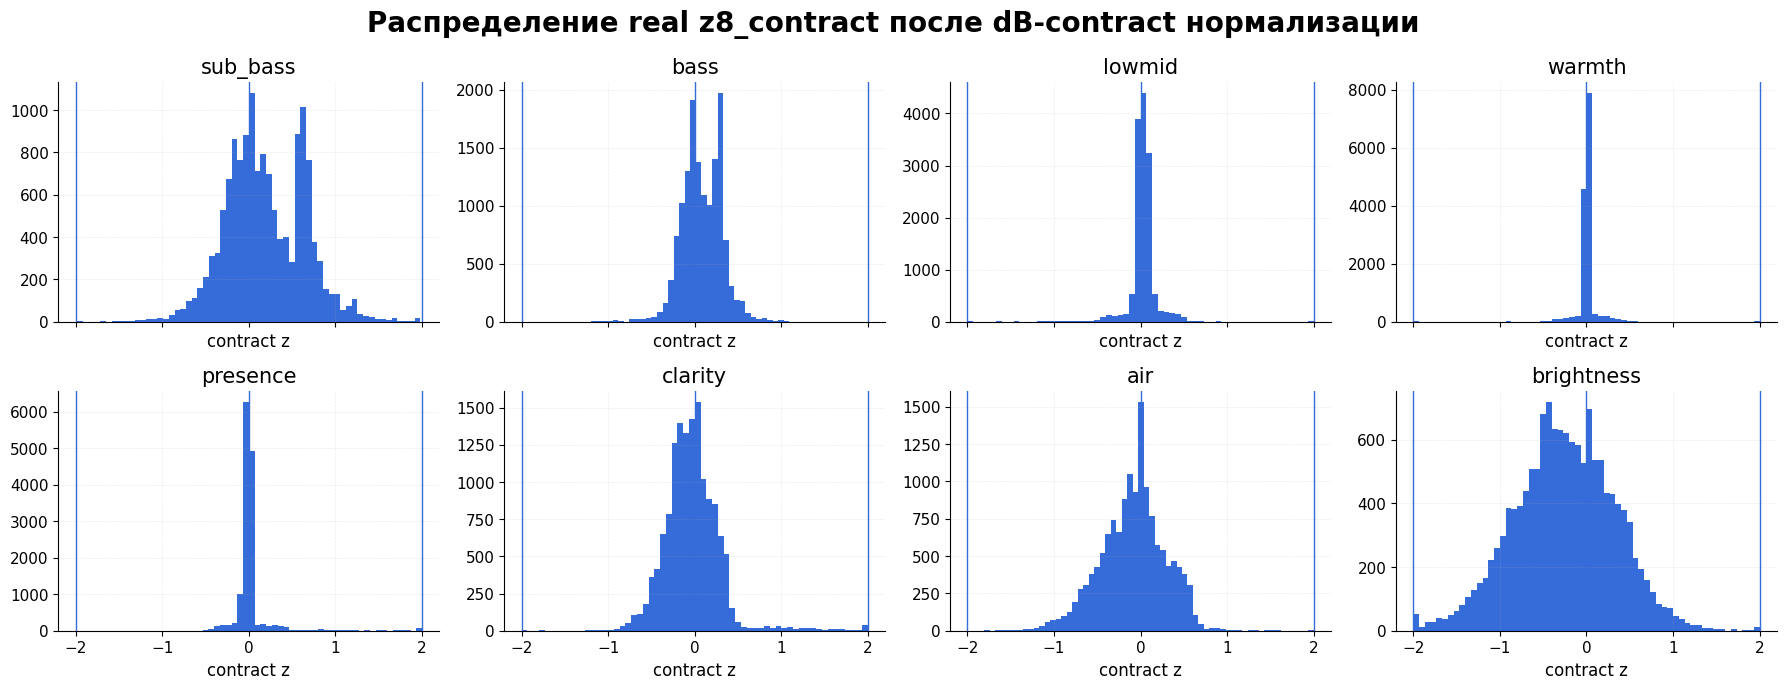

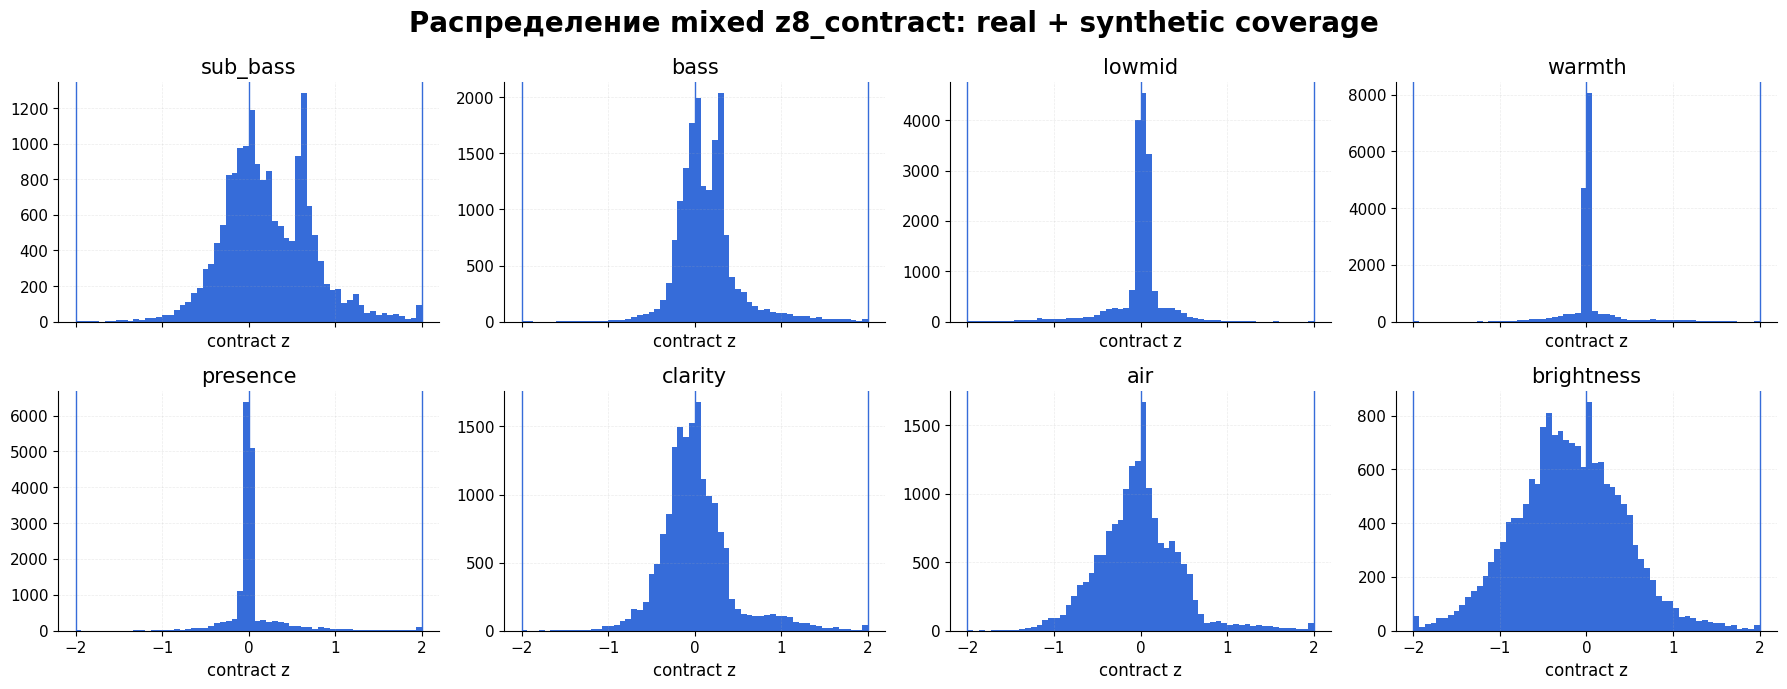

In [3]:
def vector_matrix(frame, col="z8_scaled_vector"):
    return np.stack(frame[col].values).astype(np.float32)

def plot_z_histograms(z, title, path_name, bins=60):
    fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
    axes = axes.ravel()
    for i, name in enumerate(fs.FEATURE_NAMES_8D):
        ax = axes[i]
        ax.hist(z[:, i], bins=bins)
        ax.axvline(0, linewidth=1)
        ax.axvline(-2, linewidth=1)
        ax.axvline(2, linewidth=1)
        ax.set_title(name)
        ax.set_xlabel("contract z")
        ax.grid(True, alpha=0.25)
    fig.suptitle(title, fontsize=20, fontweight="bold")
    fig.tight_layout()
    mp.save_current_figure(FIGURES_DIR / path_name)
    plt.show()

real_df = df[~df["is_synthetic"].astype(bool)].copy()
real_z = vector_matrix(real_df, "z8_scaled_vector")
mixed_z = vector_matrix(df, "z8_scaled_vector")

plot_z_histograms(
    real_z,
    "Распределение real z8_contract после dB-contract нормализации",
    "mapper_v4_02_real_z8_contract_distribution.png",
)
plot_z_histograms(
    mixed_z,
    "Распределение mixed z8_contract: real + synthetic coverage",
    "mapper_v4_02_mixed_z8_contract_distribution.png",
)


In [4]:
# Contract z coverage by source.
z_rows = []
for source_group, g in df.groupby("source_group"):
    z = vector_matrix(g, "z8_scaled_vector")
    z_abs_max = np.max(np.abs(z), axis=1)
    z_rows.append({
        "source_group": source_group,
        "rows": len(g),
        "mean_abs_z": float(np.mean(np.abs(z))),
        "mean_max_abs_z": float(np.mean(z_abs_max)),
        "p95_max_abs_z": float(np.percentile(z_abs_max, 95)),
        "max_abs_z": float(np.max(z_abs_max)),
    })
source_z_stats = pd.DataFrame(z_rows).sort_values("mean_max_abs_z", ascending=False)
source_z_stats.to_csv(METRICS_DIR / "mapper_v4_02_source_z_contract_stats.csv", index=False)
source_z_stats


,source_group,rows,mean_abs_z,mean_max_abs_z,p95_max_abs_z,max_abs_z
3,synthetic_archetype_jitter,2000,0.593258,1.286709,1.996982,2.000000
4,synthetic_axis,64,0.156250,1.250000,2.000000,2.000000
2,synthetic_archetype,7,0.579464,1.242857,1.620000,1.650000
5,synthetic_random,709,0.538640,1.220906,1.939532,2.000000
0,opra,12593,0.232876,0.657055,1.399219,2.000000
1,socialfx,1595,0.194742,0.400917,0.517023,0.561752


## 3. Target EQ strength by source

Проверяем, что SocialFX остаётся мягким, OPRA средним/сильным, а archetype synthetic покрывает сильные пользовательские профили.


,source_group,rows,mean_abs_db,mean_max_abs_db,p95_max_abs_db,max_abs_db
3,synthetic_archetype_jitter,2000,4.488358,9.967907,15.946220,16.000000
2,synthetic_archetype,7,4.518878,9.856592,15.009153,15.045159
5,synthetic_random,709,2.908632,7.661195,11.938205,15.298779
4,synthetic_axis,64,1.206174,5.483063,11.174770,12.605610
0,opra,12593,1.097051,5.302817,10.574081,19.925787
1,socialfx,1595,0.906375,1.920107,2.407842,3.459269


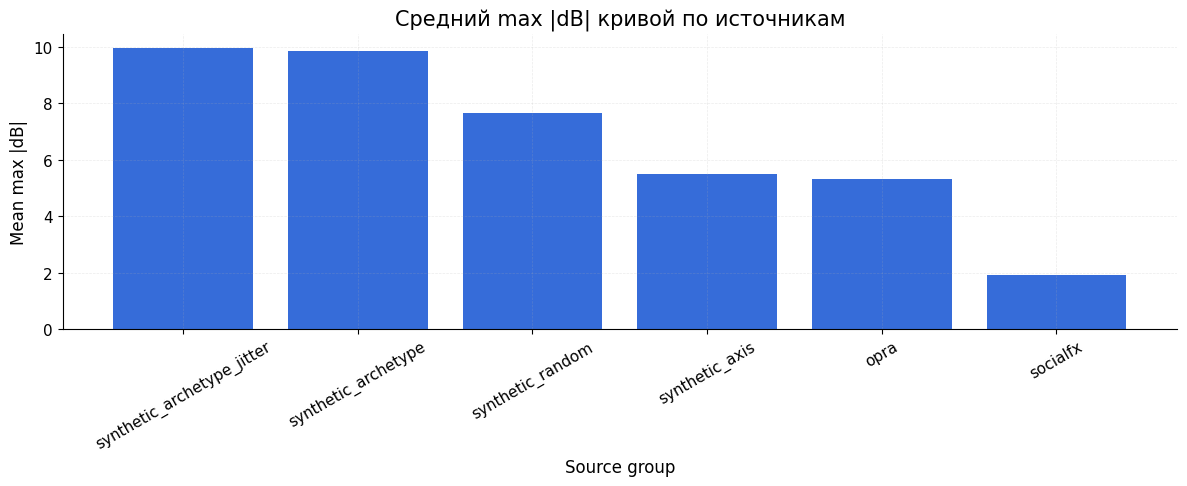

In [5]:
curve_stats = []
for source_group, g in df.groupby("source_group"):
    curves = np.stack(g["curve_23"].values).astype(np.float32)
    max_abs = np.max(np.abs(curves), axis=1)
    curve_stats.append({
        "source_group": source_group,
        "rows": len(g),
        "mean_abs_db": float(np.mean(np.abs(curves))),
        "mean_max_abs_db": float(np.mean(max_abs)),
        "p95_max_abs_db": float(np.percentile(max_abs, 95)),
        "max_abs_db": float(np.max(max_abs)),
    })
source_curve_stats = pd.DataFrame(curve_stats).sort_values("mean_max_abs_db", ascending=False)
source_curve_stats.to_csv(METRICS_DIR / "mapper_v4_02_source_curve_stats.csv", index=False)
display(source_curve_stats)

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = source_curve_stats.sort_values("mean_max_abs_db", ascending=False)
ax.bar(plot_df["source_group"], plot_df["mean_max_abs_db"])
ax.set_title("Средний max |dB| кривой по источникам")
ax.set_xlabel("Source group")
ax.set_ylabel("Mean max |dB|")
ax.tick_params(axis="x", rotation=30)
mp.save_current_figure(FIGURES_DIR / "mapper_v4_02_mean_max_abs_db_by_source.png")
plt.show()


## 4. Interpretable contract basis

`InterpretableMapper8D` здесь является **contract mapper**, а не reconstruction baseline.
Он показывает, какой EQ-профиль соответствует `z = 0.5 / 1 / 1.5 / 2`.


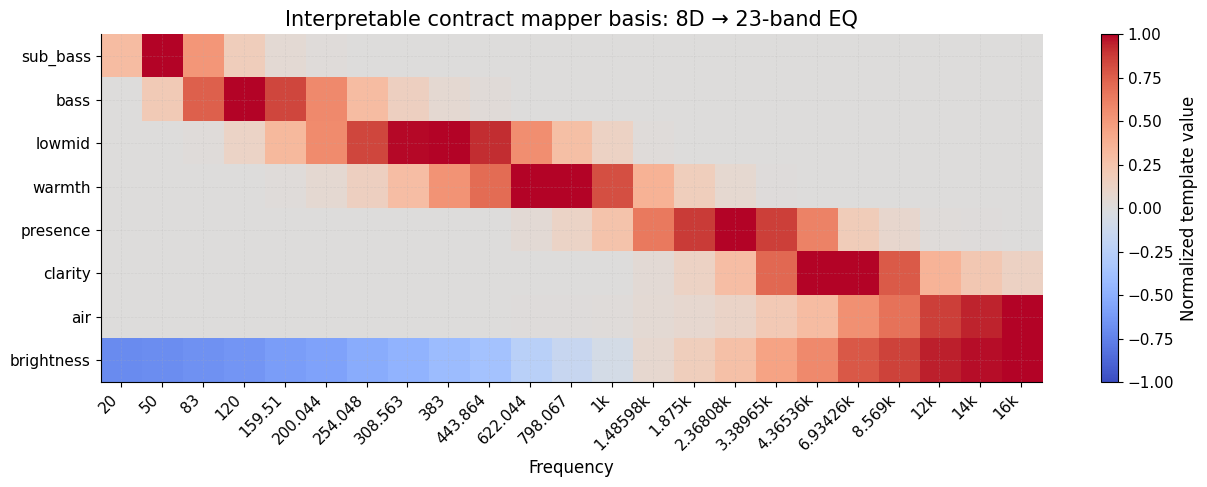

In [6]:
mapper = mb.InterpretableMapper8D(freqs_hz=freqs_23, safety=True)
mapper_raw = mb.InterpretableMapper8D(freqs_hz=freqs_23, safety=False)

fig, ax = mp.plot_basis_heatmap(
    mapper.basis_matrix,
    freqs_23,
    title="Interpretable contract mapper basis: 8D → 23-band EQ",
)
mp.save_current_figure(FIGURES_DIR / "mapper_v4_02_contract_basis_heatmap.png")
plt.show()


## 5. Contract scale sweep


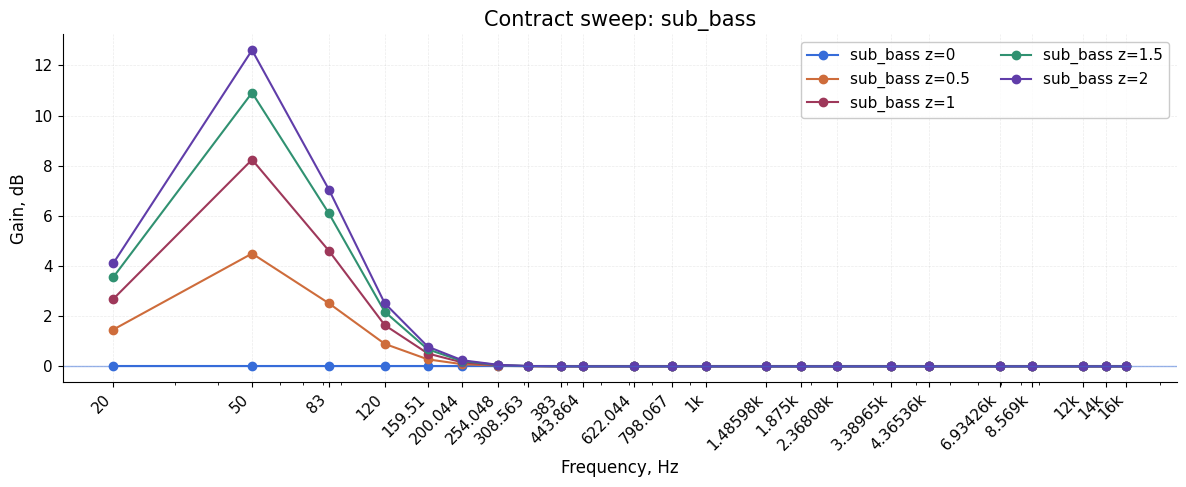

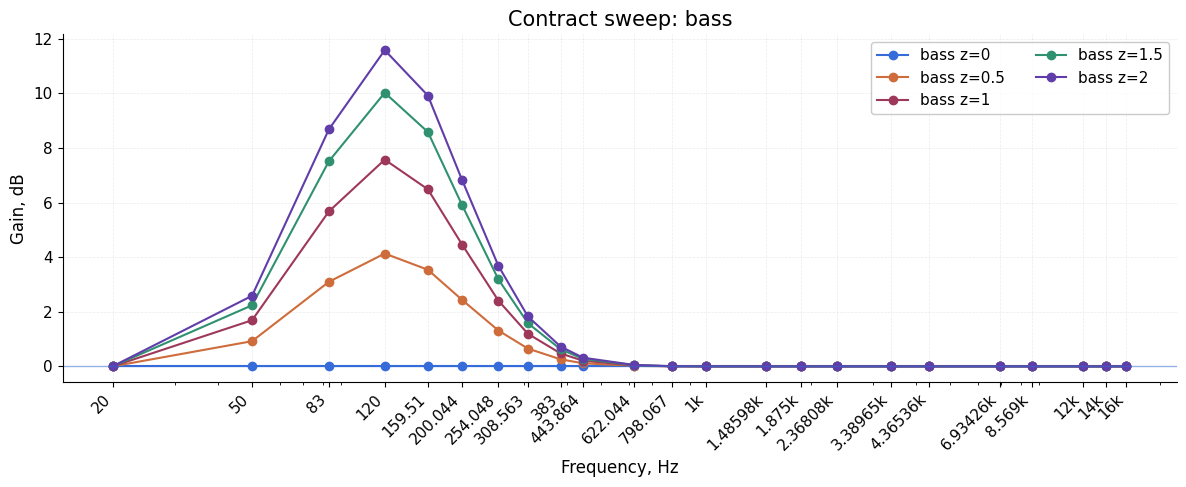

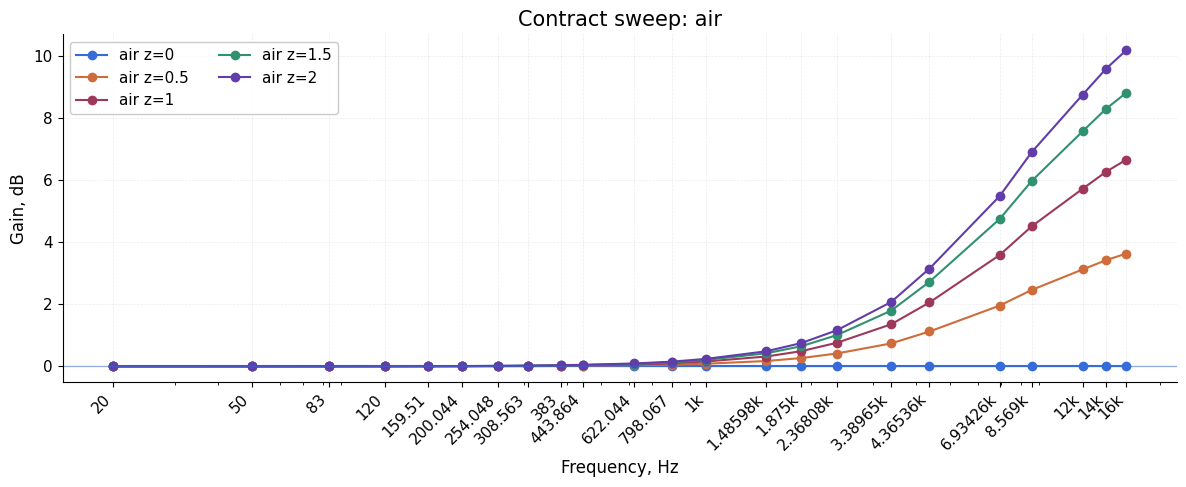

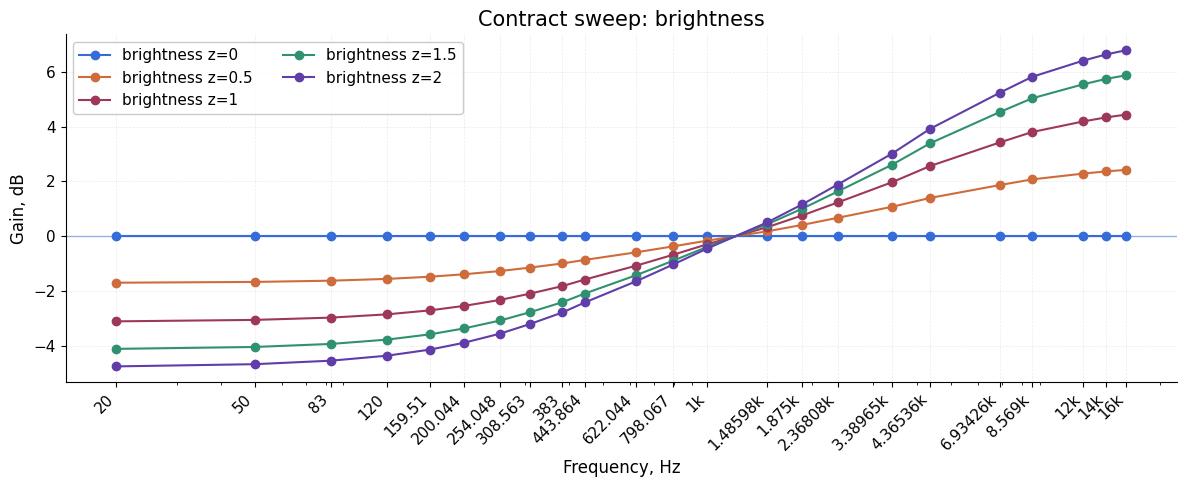

In [7]:
z_contract_values = [0.0, 0.5, 1.0, 1.5, 2.0]
features_to_plot = ["sub_bass", "bass", "air", "brightness"]

for feature in features_to_plot:
    X = mb.make_axis_sweep(feature, z_contract_values)
    curves = mapper.map_batch(X)
    curve_dict = {f"{feature} z={v:g}": c for v, c in zip(z_contract_values, curves)}
    fig, ax = mp.plot_eq_curves(
        curve_dict,
        freqs_23,
        title=f"Contract sweep: {feature}",
    )
    mp.save_current_figure(FIGURES_DIR / f"mapper_v4_02_contract_sweep_{feature}.png")
    plt.show()


## 6. Archetype examples from dataset

Если `v4_01` добавил `synthetic_archetype` / `synthetic_archetype_jitter`, смотрим их реальные target-кривые.


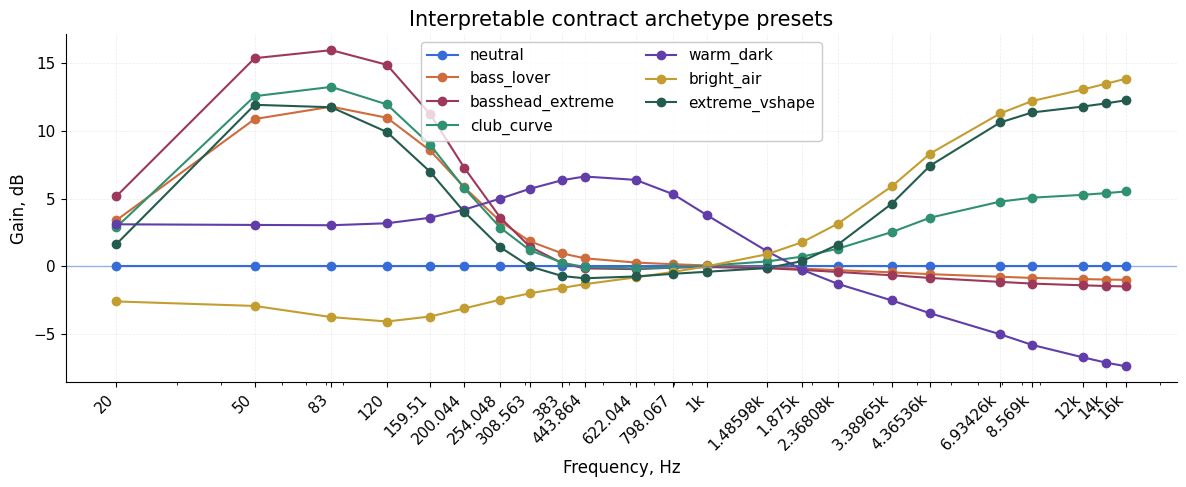

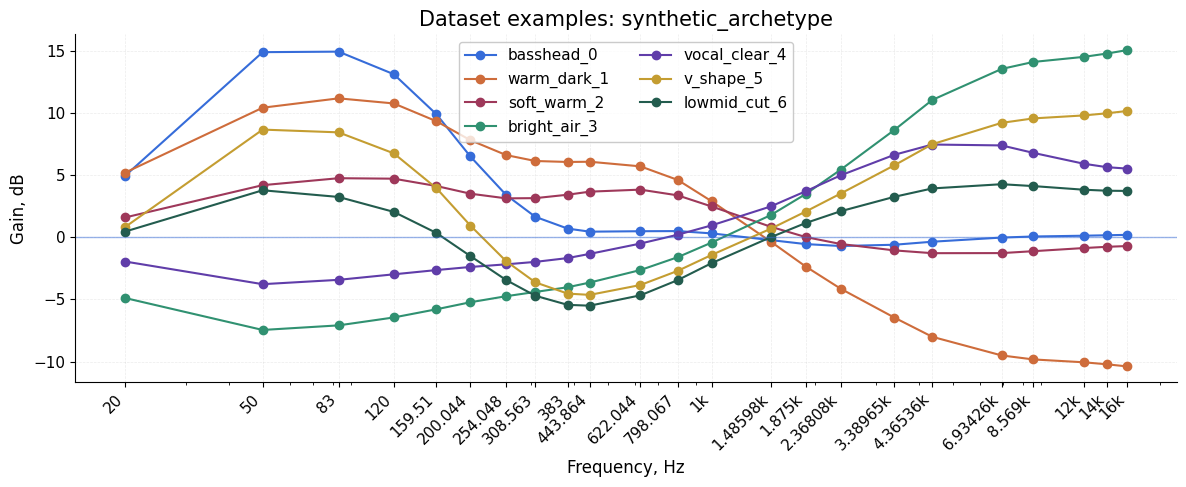

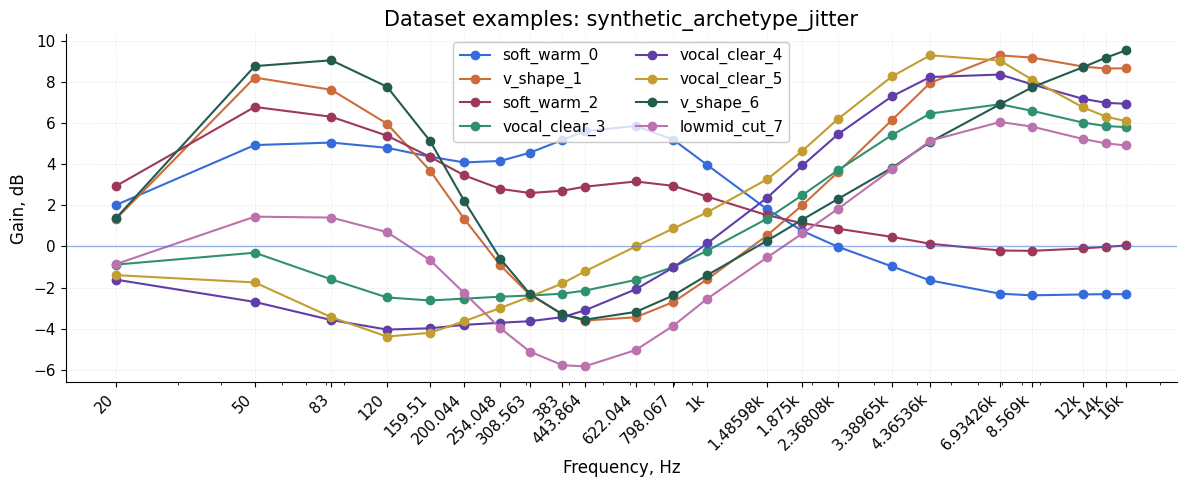

In [8]:
# Built-in mapper presets.
presets = mb.make_archetype_presets()
preset_curves = {name: mapper.map_one(z) for name, z in presets.items()}
fig, ax = mp.plot_eq_curves(preset_curves, freqs_23, title="Interpretable contract archetype presets")
mp.save_current_figure(FIGURES_DIR / "mapper_v4_02_contract_archetype_presets.png")
plt.show()

# Dataset archetypes, if present.
for source_group in ["synthetic_archetype", "synthetic_archetype_jitter"]:
    g = df[df["source_group"] == source_group]
    if len(g) == 0:
        print(f"No rows for {source_group}")
        continue
    sample = g.sample(n=min(8, len(g)), random_state=42)
    curves = {}
    for i, (_, row) in enumerate(sample.iterrows()):
        label = str(row.get("synthetic_label", source_group))
        curves[f"{label}_{i}"] = np.asarray(row["curve_23"], dtype=np.float32)
    fig, ax = mp.plot_eq_curves(curves, freqs_23, title=f"Dataset examples: {source_group}")
    mp.save_current_figure(FIGURES_DIR / f"mapper_v4_02_examples_{source_group}.png")
    plt.show()


## 7. Cycle consistency

Проверяем цикл:

```text
z_contract → interpretable mapper → EQ → extractor + contract normalizer → z_reconstructed
```

Это не обязано быть идеальным, но помогает увидеть, насколько extractor и generative basis согласованы.


In [9]:
rng = np.random.default_rng(42)

# Random z, but not pure full-cube uniform: closer to expected live values.
z_random = rng.normal(0.0, 0.8, size=(512, len(fs.FEATURE_NAMES_8D))).astype(np.float32)
z_random = np.clip(z_random, -2.0, 2.0)

# Add axis anchors.
axis_values = [-2.0, -1.0, 0.0, 1.0, 2.0]
axis_rows = [mb.make_axis_sweep(feature, axis_values) for feature in fs.FEATURE_NAMES_8D]
z_cycle = np.concatenate([z_random, *axis_rows], axis=0).astype(np.float32)

cycle_df = mm.compute_cycle_consistency(mapper.map_batch, z_cycle, freqs_23, normalizer)
cycle_df.to_csv(METRICS_DIR / "mapper_v4_02_contract_cycle_consistency.csv", index=False)
cycle_df


,feature,cycle_mae,cycle_mse,cycle_corr
0,sub_bass,0.370895,0.222332,0.774096
1,bass,0.319044,0.168888,0.841205
2,lowmid,0.553061,0.486798,0.685928
3,warmth,0.421467,0.280879,0.766751
4,presence,0.583359,0.521040,0.649040
5,clarity,0.773831,0.921250,0.498970
6,air,0.436927,0.285429,0.764736
7,brightness,0.755984,0.852969,0.681691
8,__overall__,0.526821,0.467448,0.676221


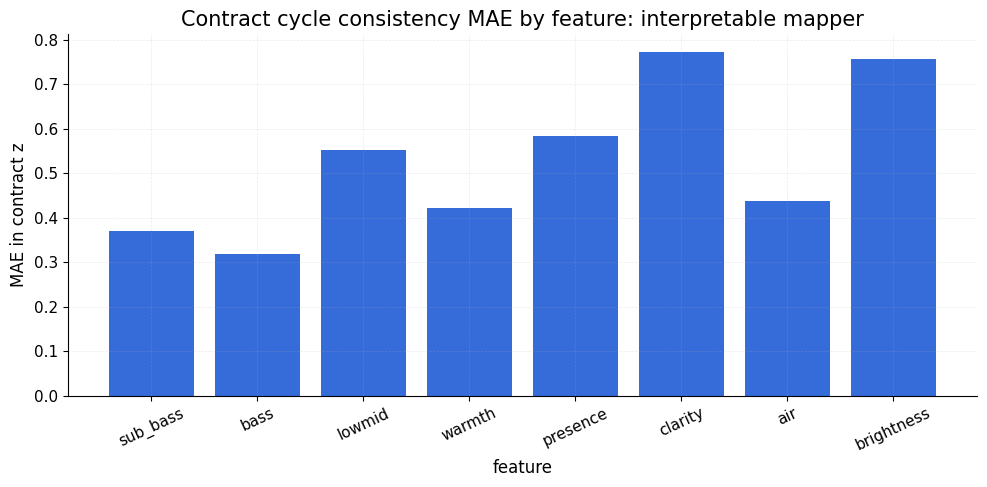

In [10]:
fig, ax = mp.plot_metric_bar(
    cycle_df[cycle_df["feature"] != "__overall__"],
    x="feature",
    y="cycle_mae",
    title="Contract cycle consistency MAE by feature: interpretable mapper",
    ylabel="MAE in contract z",
)
mp.save_current_figure(FIGURES_DIR / "mapper_v4_02_contract_cycle_consistency_mae.png")
plt.show()


## 8. Controllability / scale metrics


In [11]:
align_df = mm.compute_basis_alignment(mapper.map_batch, freqs_23)
slopes_df = mm.collect_sweep_slopes(mapper.map_batch, freqs_23)
sens_df = mm.summarize_sweep_sensitivity(slopes_df, freqs_23)
scale_df = mm.compute_scale_sweep_metrics(mapper.map_batch, freqs_23)
extreme_df = mm.compute_extreme_coverage(mapper.map_batch, freqs_23)

metrics_df = (
    align_df
    .merge(sens_df, on="feature")
    .merge(scale_df, on="feature")
    .merge(extreme_df, on="feature")
)
metrics_df.to_csv(METRICS_DIR / "mapper_v4_02_contract_interpretable_mapper_metrics.csv", index=False)
metrics_df


,feature,basis_alignment,target_response,off_response,target_off_ratio,sign_consistency,max_abs_slope,monotonicity_score,target_energy_z0,target_energy_z2,scale_gain_z2_minus_z0,extreme_peak_abs_db,extreme_mean_abs_target_db,extreme_mean_abs_off_db
0,sub_bass,0.998482,4.508720,0.279349,16.140100,1.000,6.757409,1.0,0.0,8.354764,8.354764,12.605610,8.354764,0.508349
1,bass,0.999769,4.512356,0.389651,11.580494,1.000,6.379701,1.0,0.0,8.193843,8.193843,11.584694,8.193843,0.707556
2,lowmid,0.999935,2.394897,0.234295,10.221703,1.000,2.786122,1.0,0.0,4.348816,4.348816,5.059229,4.348816,0.425449
3,warmth,0.999844,1.779638,0.125913,14.133828,1.000,2.756321,1.0,0.0,3.231588,3.231588,5.005114,3.231588,0.228642
4,presence,0.999840,1.692250,0.143504,11.792329,1.000,2.299665,1.0,0.0,3.072901,3.072901,4.175887,3.072901,0.260585
5,clarity,0.999836,2.916808,0.325633,8.957340,1.000,3.222708,1.0,0.0,5.296537,5.296537,5.852012,5.296537,0.591307
6,air,0.999962,4.874375,0.398278,12.238624,1.000,5.605806,1.0,0.0,8.851219,8.851219,10.179403,8.851219,0.723220
7,brightness,0.999990,2.513922,0.762225,3.298134,0.625,3.737204,1.0,0.0,4.564949,4.564949,6.786269,4.564949,1.384101


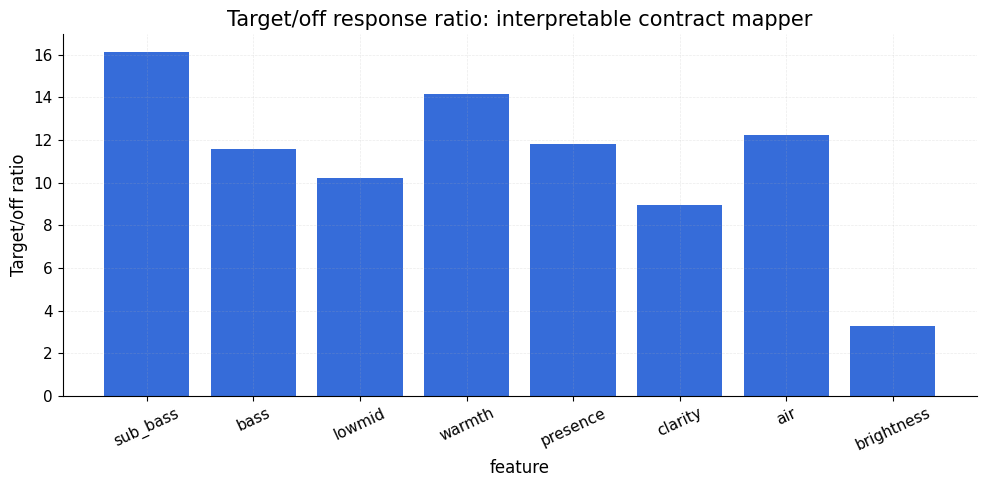

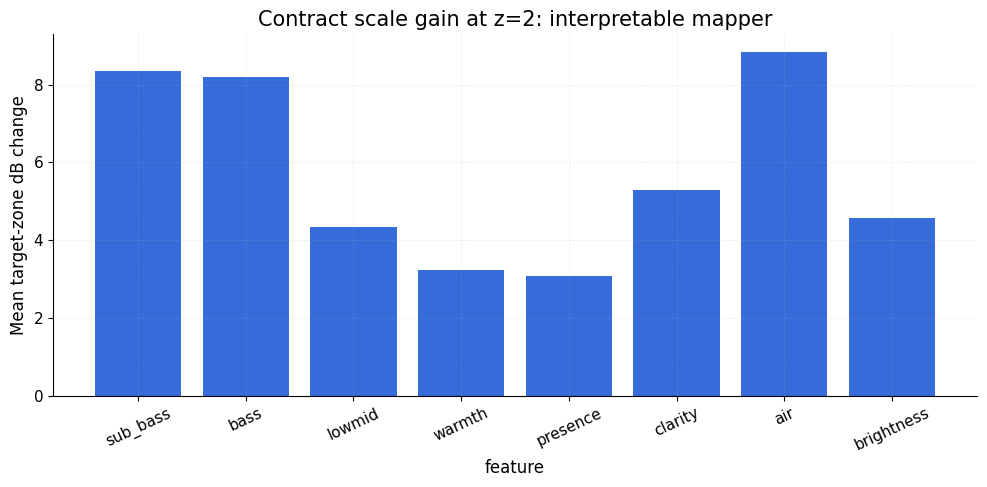

In [12]:
fig, ax = mp.plot_metric_bar(
    metrics_df,
    x="feature",
    y="target_off_ratio",
    title="Target/off response ratio: interpretable contract mapper",
    ylabel="Target/off ratio",
)
mp.save_current_figure(FIGURES_DIR / "mapper_v4_02_contract_target_off_ratio.png")
plt.show()

fig, ax = mp.plot_metric_bar(
    metrics_df,
    x="feature",
    y="scale_gain_z2_minus_z0",
    title="Contract scale gain at z=2: interpretable mapper",
    ylabel="Mean target-zone dB change",
)
mp.save_current_figure(FIGURES_DIR / "mapper_v4_02_contract_scale_gain.png")
plt.show()


## Вывод

`v4_02` теперь проверяет не percentile-нормализацию, а **dB-contract шкалу** и поведение ручного mapper-а в этой шкале.

Следующий ноутбук `v4_03` должен обучать learned mapper на том же `z8_scaled_vector`, который теперь по смыслу равен `z8_contract_vector`, и обязательно считать метрики отдельно по `source_group`.
